In [1]:
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.nn.utils import rnn as rnn_utils
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle, Rectangle
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': 'black',
    'axes.facecolor': 'black',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'grid.color': '#444444',
    'grid.alpha': 0.3,
    'legend.facecolor': 'black',
    'legend.edgecolor': 'white',
})

torch.manual_seed(42)
np.random.seed(42)

# <font color="#00FFFF" > **第五章 循环神经网络**</font>

## **本章内容**
> 1. **序列数据与循环神经网络**
> 2. **门控循环单元（GRU）**
> 3. **长短时记忆网络（LSTM）**
> 4. **变长序列处理：Padding与Packing**
> 5. **1D卷积在序列数据上的应用**
> 6. **PyTorch实现综合案例**

##  <font color="#FFEA00" >**第一节 序列数据与循环神经网络**</font>

### <font color="#39FF14" size=6 >**一、什么是序列数据？**</font>

#### <font color="#CCFF00" >**序列数据的特点</font>**

序列数据（Sequential Data）是指**有序的数据点集合**，数据点之间存在**顺序关系**。

<font color="#FF00A0" >**核心概念：Sequential Memory**</font>

<font color="#f6ff00">**序列记忆**</font>是一种让大脑更容易记住序列特征的机制。

#### <font color="#CCFF00">**为什么 MLP/CNN 不擅长序列建模？**</font>

##### <font color="#00ffbf">**核心矛盾：结构设计与序列特性的不匹配**</font>

<font color="#f6ff00">**1. 固定输入维度的限制**</font>

- MLP：输入层神经元数量固定 → 无法直接处理变长序列
- CNN：需要固定大小的张量 → 变长序列需 padding/truncate

<font color="#f6ff00">**2. 缺乏显式的时间/顺序建模机制**</font>
- MLP：全连接，位置之间无差别对待
- CNN：卷积核在空间/时间上滑动，但每个时间步的滤波器输出独立，无状态传递

<font color="#f6ff00">**3. 长程依赖困难**</font>
- MLP: 无记忆机制，远距离输入需通过深层网络间接联系
- CNN: 感受野受限（除非堆叠极多层或特殊设计）

### <font color="#39FF14">**二、循环神经网络的核心思想**</font>

#### <font color="#CCFF00" >**RNN的循环连接</font>**

RNN通过引入<font color="#f6ff00">**隐藏状态（Hidden State）**</font>来传递序列信息


<font color="#FF00A0" >**关键特性**</font>：
- <font color="#f6ff00">**参数共享**</font>：同一组参数处理所有时间步
- **记忆能力**：隐藏状态保存历史信息
- **变长处理**：可处理任意长度的序列


<font color="#f6ff00">**RNN单元只有一个！**</font>它会学习一组特定的权重和偏置，并且会在序列的每一步中都以完全相同的方式对输入进行转换。

##### <font color="#00ffbf">**循环神经网络的核心目标：就是产生一个能够最好地表示一个序列的隐藏状态**</font>


<font color="#f6ff00">**1. "隐藏状态"**</font>= 记忆的压缩表示


<font color="#f6ff00">**2. "表示一个序列"**</font> = 信息浓缩


<font color="#f6ff00">**3. "最好地"**</font>= 针对下游任务优化


  RNN 通过循环更新机制，将变长的序列信息"蒸馏"成一个固定维度的向量（隐藏状态），这个向量就是网络对整个序列的"理解"，且会根据下游任务（如分类、生成）的要求自动学习"什么该记住、什么该遗忘"。

In [2]:
# RNN隐藏状态更新可视化
def rnn_step(x_t, h_prev, W_xh, W_hh, b_h):
    """
    单步RNN计算
    x_t: 当前输入 (input_size,)
    h_prev: 前一隐藏状态 (hidden_size,)
    W_xh: 输入到隐藏的权重
    W_hh: 隐藏到隐藏的权重
    b_h: 隐藏层偏置
    """
    # 隐藏状态更新: h_t = tanh(W_xh @ x_t + W_hh @ h_prev + b_h)
    h_t = np.tanh(W_xh @ x_t + W_hh @ h_prev + b_h)
    return h_t

# 示例参数
input_size = 3
hidden_size = 4

# 随机初始化权重
W_xh = np.random.randn(hidden_size, input_size) * 0.1
W_hh = np.random.randn(hidden_size, hidden_size) * 0.1
b_h = np.zeros(hidden_size)

# 序列数据 (3个时间步)
sequence = [
    np.array([1.0, 0.5, -0.5]),   # t=0
    np.array([0.8, 0.3, -0.3]),   # t=1
    np.array([0.6, 0.2, -0.2]),   # t=2
]

# 初始隐藏状态
h = np.zeros(hidden_size)

print("=== RNN隐藏状态更新过程 ===\n")
print(f"初始隐藏状态 h_0: {h}\n")

hidden_states = [h.copy()]

for t, x_t in enumerate(sequence):
    h = rnn_step(x_t, h, W_xh, W_hh, b_h)
    hidden_states.append(h.copy())
    print(f"时间步 {t+1}:")
    print(f"  输入 x_{t+1}: {x_t}")
    print(f"  隐藏状态 h_{t+1}: {h.round(4)}")
    print()

print("注意：隐藏状态在每个时间步都在更新，携带了历史信息")

=== RNN隐藏状态更新过程 ===

初始隐藏状态 h_0: [0. 0. 0. 0.]

时间步 1:
  输入 x_1: [ 1.   0.5 -0.5]
  隐藏状态 h_1: [0.0104 0.1511 0.2163 0.0543]

时间步 2:
  输入 x_2: [ 0.8  0.3 -0.3]
  隐藏状态 h_2: [-0.0528  0.0979  0.154   0.0217]

时间步 3:
  输入 x_3: [ 0.6  0.2 -0.2]
  隐藏状态 h_3: [-0.0337  0.0826  0.1071  0.0196]

注意：隐藏状态在每个时间步都在更新，携带了历史信息


##### <font color="#00ffbf">**输出结果分析</font>**

**观察要点**：
1. **隐藏状态的变化**：每个时间步的隐藏状态 $h_t$ 都在变化，说明模型正在处理序列信息
2. **信息累积**：后期的隐藏状态包含了前面所有时间步的信息
3. **数值范围**：由于使用了 $\tanh$ 激活函数，隐藏状态的值被限制在 $(-1, 1)$ 之间

**关键理解**：
- 初始状态 $h_0$ 为零向量，表示\"没有历史信息\"
- 随着时间步推进，隐藏状态逐渐携带更多上下文信息
- 这正是RNN能够处理序列数据的核心机制

### <font color="#39FF14">**三、RNN Layer**</font>

#### <font color="#CCFF00" >**RNN Cell内部结构</font>**


**数学表示**（分解版）：

\begin{aligned}
t_{h} & =W_{h h} \quad h_{t-1}+b_{h h} \quad \text{(蓝色：变换隐藏状态)}\\
t_{x} & =W_{i h} \quad x_{t}+b_{i h} \quad \text{(红色：变换输入数据)}\\
h_{t} & =\tanh \quad\left(t_{h}+t_{x}\right)\quad \text{(输出：新隐藏状态)}
\end{aligned}


#### <font color="#CCFF00" >**RNN Layer vs RNN Cell：两种使用方式</font>**

PyTorch 提供了两种 RNN 接口，适用于不同场景：

| 特性 | `nn.RNNCell` | `nn.RNN` |
|:---:|:---|:---|
| **处理粒度** | 单个时间步 | 整个序列 |
| **使用方式** | 手动循环 | 自动处理 |
| **输入形状** | `(N, F)` - 单个时间步 | `(L, N, F)` 或 `(N, L, F)` - 整个序列 |
| **隐藏状态** | 需手动传递 `h_t` | 自动管理，可返回最终状态 |
| **典型场景** | 需自定义循环逻辑时 | 标准序列建模 |
| **代码复杂度** | 较繁琐 | 简洁 |

**核心区别**：
- `nn.RNNCell`：底层接口，处理**单个时间步**，需要手动写循环，但灵活可控
- `nn.RNN`：高层封装，处理**整个序列**，自动管理时间步循环

---

##### <font color="#00ffbf">**nn.RNNCell 的适用场景**</font>

虽然 `nn.RNN` 更常用，但 `nn.RNNCell` 在以下场景不可替代：

| 场景 | 说明 |
|:---|:---|
| **注意力机制** | 在循环中插入注意力计算（如 Seq2Seq + Attention） |
| **自回归生成** | 下一步输入依赖当前输出（如 GPT 逐个 token 生成） |
| **条件处理** | 循环中需要条件分支（如根据当前状态决定是否重置） |
| **非标准结构** | 多模态融合、辅助任务等复杂架构 |

<font color="#FF00A0">**类比**</font>：
- `nn.RNN` = 全自动洗衣机，一键完成标准流程
- `nn.RNNCell` = 手动洗衣，可在任意步骤加漂洗、脱水，适合特殊需求

---

##### <font color="#00ffbf">**nn.RNN 的主要参数**</font>

| 参数 | 含义 | 默认值 | 备注 |
|:-----|:-----|:------:|:-----|
| `input_size` | 每个数据点的特征数 | - | 必须指定 |
| `hidden_size` | 隐藏状态维度 | - | 决定模型容量 |
| `num_layers` | 堆叠层数 | 1 | 多层 RNN |
| `bias` | 是否使用偏置 | True | 通常保持默认 |
| `batch_first` | 批次维度是否为第一维 | False | 建议设为 `True` |
| `bidirectional` | 是否双向 | False | 双向 RNN |
| `dropout` | 层间 dropout 概率 | 0 | 仅多层时有效 |
| `nonlinearity` | 激活函数 | 'tanh' | 可选 'tanh' 或 'relu' |

---

##### <font color="#00ffbf">**输入输出形状对比**</font>

**`nn.RNNCell`（单步）**：
```
输入:  x_t   (N, F)    - 当前时间步输入
       h_prev (N, H)   - 上一时刻隐藏状态
输出:  h_t   (N, H)    - 当前时刻隐藏状态
```

**`nn.RNN`（序列）**：
```
输入:  x      (L, N, F) 或 (N, L, F) - 整个序列
       h_0    (num_layers, N, H)      - 初始隐藏状态（可选）
输出:  output (L, N, H) 或 (N, L, H)  - 所有时间步的隐藏状态
       h_n    (num_layers, N, H)      - 最终隐藏状态
```

其中：
- `N` = batch_size（批次大小）
- `L` = sequence_length（序列长度）
- `F` = input_size（输入特征维度）
- `H` = hidden_size（隐藏状态维度）


#### <font color="#CCFF00" >**RNN的输入输出Shape详解</font>**

<font color="#FF00A0" size=5>**⚠️ 形状是最容易混淆的地方！**</font>

---

##### <font color="#00ffbf">**关键对比：DataLoader输出 vs RNN输入**</font>

| 来源 | 默认Shape | 说明 | 冲突点 |
|:---:|:---:|:---|:---|
| **DataLoader** | `(N, L, F)` | batch-first，符合直觉 | RNN默认不匹配！ |
| **nn.RNN** | `(L, N, F)` | sequence-first，历史遗留 | 需要调整 |

**解决方案**：设置 `batch_first=True`，使 RNN 与 DataLoader 保持一致

---

##### <font color="#00ffbf">**输入形状详解**</font>

| 参数设置 | 输入Shape | 说明 |
|:---:|:---:|:---|
| **默认** | `(L, N, F)` | sequence-first：序列长度在前 |
| **batch_first=True** | `(N, L, F)` | batch-first：批次大小在前（**推荐**） |
| **PackedSequence** | 特殊格式 | 变长序列打包，用于加速训练 |

其中：
- `N` = batch_size（批次大小）
- `L` = sequence_length（序列长度）
- `F` = input_size（输入特征维度）

---

##### <font color="#00ffbf">**隐藏状态形状详解**</font>

| RNN类型 | 初始/最终隐藏状态Shape | 说明 |
|:---:|:---:|:---|
| **单层单向** | `(1, N, H)` | 1层，1个方向 |
| **多层** | `(num_layers, N, H)` | 每层一个隐藏状态 |
| **双向** | `(2*num_layers, N, H)` | 每层2个方向（前向+后向） |

其中 `H` = hidden_size（隐藏状态维度）

---

##### <font color="#00ffbf">**输出形状详解**</font>

| 配置 | 输出Shape | 说明 |
|:---:|:---:|:---|
| 默认 | `(L, N, H)` | 所有时间步的隐藏状态 |
| batch_first=True | `(N, L, H)` | 同上，批次维度在前 |
| 双向（`batch_first=True`） | `(N, L, 2*H)` | 两个方向隐藏状态拼接 |

**返回值**：`output, final_hidden`
- `output`：每个时间步的隐藏状态（用于序列标注等任务）
- `final_hidden`：最后时刻的隐藏状态（用于分类等任务）

---

##### <font color="#00ffbf">**⚠️ 常见陷阱：双向RNN的特殊性**</font>

```python
# 对于单向RNN：output[:, -1] == final_hidden[-1]  ✓
# 对于双向RNN：output[:, -1] != final_hidden      ✗
```

**原因**：
- `output[:, -1]` = [正向在 t=L-1 的状态 | 反向在 t=L-1 的状态] 的拼接
    - `final_hidden[0]` = 正向在 t=L-1 的状态（正向最后时刻）
    - `final_hidden[1]` = 反向在 t=0 的状态（反向处理完整个序列后的最终状态）

---

##### <font color="#00ffbf">**代码示例：Shape验证**</font>


In [3]:
# RNN Shape 验证示例
import torch
import torch.nn as nn

# 参数设置
N, L, F, H = 2, 5, 10, 16  # batch, seq_len, input_size, hidden_size

# 模拟 DataLoader 输出 (batch_first=True)
x_batch_first = torch.randn(N, L, F)
print(f"DataLoader输出 shape: {x_batch_first.shape}")  # (N, L, F)

print("\n" + "="*60)
print("对比1：batch_first=False (默认)")
print("="*60)

# 默认：batch_first=False
rnn_default = nn.RNN(input_size=F, hidden_size=H, batch_first=False)

# 需要转置！容易出错
x_seq_first = x_batch_first.transpose(0, 1)  # (L, N, F)
output, final_hidden = rnn_default(x_seq_first)

print(f"输入 shape: {x_seq_first.shape}    (L, N, F)")
print(f"输出 shape: {output.shape}    (L, N, H)")
print(f"最终隐藏状态: {final_hidden.shape}    (1, N, H)")

print("\n" + "="*60)
print("对比2：batch_first=True (推荐)")
print("="*60)

# 推荐：batch_first=True
rnn_batch_first = nn.RNN(input_size=F, hidden_size=H, batch_first=True)

# 直接输入，无需转置
output2, final_hidden2 = rnn_batch_first(x_batch_first)

print(f"输入 shape: {x_batch_first.shape}    (N, L, F)")
print(f"输出 shape: {output2.shape}    (N, L, H)")
print(f"最终隐藏状态: {final_hidden2.shape}    (1, N, H)")

print("\n" + "="*60)
print("验证：output[:, -1] 与 final_hidden 的关系")
print("="*60)

# 单向RNN：output[:, -1] 应该等于 final_hidden[-1]
last_output = output2[:, -1, :]  # 取每个batch的最后一个时间步
print(f"output[:, -1] shape: {last_output.shape}")
print(f"final_hidden[-1] shape: {final_hidden2[-1].shape}")
print(f"是否相等: {torch.allclose(last_output, final_hidden2[-1])}")


DataLoader输出 shape: torch.Size([2, 5, 10])

对比1：batch_first=False (默认)
输入 shape: torch.Size([5, 2, 10])    (L, N, F)
输出 shape: torch.Size([5, 2, 16])    (L, N, H)
最终隐藏状态: torch.Size([1, 2, 16])    (1, N, H)

对比2：batch_first=True (推荐)
输入 shape: torch.Size([2, 5, 10])    (N, L, F)
输出 shape: torch.Size([2, 5, 16])    (N, L, H)
最终隐藏状态: torch.Size([1, 2, 16])    (1, N, H)

验证：output[:, -1] 与 final_hidden 的关系
output[:, -1] shape: torch.Size([2, 16])
final_hidden[-1] shape: torch.Size([2, 16])
是否相等: True


#### <font color="#CCFF00" >**输出结果分析</font>**

**关键观察点**：

| 对比项 | batch_first=False | batch_first=True |
|:---|:---|:---|
| **输入shape** | `(L, N, F)` 需手动转置 | `(N, L, F)` 与DataLoader一致 |
| **输出shape** | `(L, N, H)` | `(N, L, H)` |
| **易错指数** | ⭐⭐⭐⭐⭐ | ⭐⭐ |

**核心结论**：

1. **务必使用 `batch_first=True`**：与DataLoader输出保持一致，避免手动转置出错

2. **隐藏状态形状始终为 `(num_layers, N, H)`**：不受 `batch_first` 影响！

3. **`output[:, -1]` 与 `final_hidden` 的关系**（以下基于 `batch_first=True`）：
   - 单向RNN：`output[:, -1] == final_hidden[-1]` ✓
   - 双向RNN：`output[:, -1]` 包含 [正向在 t=L-1 的状态 | 反向在 t=L-1 的状态] 的拼接，不等于 `final_hidden`
       - `final_hidden[0]` = 正向最后时刻（t=L-1）
       - `final_hidden[1]` = 反向最终状态（t=0，即原序列开头）

### <font color="#39FF14">**四、堆叠RNN（Stacked RNN）**</font>

#### <font color="#CCFF00" >**堆叠RNN的原理**</font>

堆叠RNN：将多个RNN层堆叠在一起，前一层的输出作为后一层的输入。


<font color="#FF00A0">**注意**</font>：
- 两层堆叠RNN已经计算代价很高（时间上的顺序依赖 + 层间的顺序依赖）
- 输出是**最后一层**的隐藏状态序列
- 每层的最终隐藏状态会被保存

---

##### <font color="#00ffbf">**参数量计算**</font>

堆叠RNN的计算成本随层数线性增长：

```python
# 单层RNN参数量（单向）
单层参数量 = (input_size + hidden_size) * hidden_size + hidden_size

# 堆叠L层RNN参数量（单向）
总参数量 = [(input_size + hidden_size) * hidden_size + hidden_size]        # 第1层
           + (L-1) * [(hidden_size + hidden_size) * hidden_size + hidden_size]  # 第2~L层
# 简化公式（假设 input_size ≈ hidden_size，常见于嵌入维度等于隐藏维度时）
总参数量 ≈ L × (2 * hidden_size² + hidden_size)
```
<font color="#FF00A0">**示例**</font>：input_size = hidden_size = 256 时，单层 ≈ 131K，层数每加 1 约增加 131K

<font color="#FF00A0">**关键洞察**</font>：层数增加带来表达能力提升，但也增加了梯度消失风险和过拟合可能。

---

##### <font color="#00ffbf">**代码示例：Shape演示**</font>


In [4]:
# 堆叠RNN Shape演示
import torch
import torch.nn as nn

# 参数设置
N, L, F, H, num_layers = 2, 10, 32, 64, 3  # 3层堆叠

print("="*60)
print("堆叠RNN Shape演示")
print("="*60)

# 创建3层堆叠RNN
stacked_rnn = nn.RNN(
    input_size=F,
    hidden_size=H,
    num_layers=num_layers,  # 关键参数：堆叠层数
    batch_first=True,
    bidirectional=False
)

# 输入数据 (模拟DataLoader输出)
x = torch.randn(N, L, F)
print(f"\n输入 shape: {x.shape}")  # (N, L, F)
print(f"  N={N}: batch_size (批次大小)")
print(f"  L={L}: sequence_length (序列长度)")
print(f"  F={F}: input_size (输入特征维度)")

# 前向传播
output, final_hidden = stacked_rnn(x)

print(f"\n输出 shape: {output.shape}")
print(f"  → 最后一层所有时间步的隐藏状态 (N, L, H)")

print(f"\n最终隐藏状态: {final_hidden.shape}")
print(f"  → 每层最后时刻的隐藏状态 (num_layers, N, H)")

# 逐层查看
print("\n逐层最终状态：")
for i in range(num_layers):
    print(f"  第{i+1}层: {final_hidden[i].shape} - 最后时刻状态")


堆叠RNN Shape演示

输入 shape: torch.Size([2, 10, 32])
  N=2: batch_size (批次大小)
  L=10: sequence_length (序列长度)
  F=32: input_size (输入特征维度)

输出 shape: torch.Size([2, 10, 64])
  → 最后一层所有时间步的隐藏状态 (N, L, H)

最终隐藏状态: torch.Size([3, 2, 64])
  → 每层最后时刻的隐藏状态 (num_layers, N, H)

逐层最终状态：
  第1层: torch.Size([2, 64]) - 最后时刻状态
  第2层: torch.Size([2, 64]) - 最后时刻状态
  第3层: torch.Size([2, 64]) - 最后时刻状态


#### <font color="#CCFF00" >**输出结果分析</font>**

**关键观察点**：

| 变量 | Shape | 含义 | 使用场景 |
|:---|:---:|:---|:---|
| `output` | `(N, L, H)` | **最后一层**所有时间步的隐藏状态 | 序列标注、语言模型 |
| `final_hidden` | `(num_layers, N, H)` | 每层最后时刻的隐藏状态 | 分类任务、序列编码 |
| `final_hidden[-1]` | `(N, H)` | 最后一层最后时刻状态 | 句子分类（推荐） |

**核心区别**：
- `output` 包含**所有时间步**的信息 → 用于需要每个位置输出的任务
- `final_hidden[-1]` 只包含**最后时刻**的信息 → 用于整个序列的表示

### <font color="#39FF14">**五、双向RNN（Bidirectional RNN）**</font>

#### <font color="#CCFF00" >**为什么需要双向RNN？</font>**

传统RNN只考虑**过去的信息**（从左到右），这被称为**因果RNN**（Causal RNN）,但很多时候，**未来的上下文**对理解当前位置至关重要：

##### <font color="#00ffbf">**单向 vs 双向：特征对比**</font>

| 特性 | 单向RNN | 双向RNN |
|:---:|:---|:---|
| **信息方向** | 仅过去 → 现在 | 过去 + 未来 → 现在 |
| **适用任务** | 实时生成、语言建模 | 序列标注、文本分类 |
| **延迟要求** | 无延迟，可实时 | 需完整序列，有延迟 |
| **表达能力** | 有限 | 更强（全局上下文） |
| **参数量** | 标准 | 2×（两个方向独立计算） |
| **计算成本** | 标准 | 2×（可并行） |

**双向RNN同时考虑过去和未来！**

<font color="#FF00A0">**关键洞察**</font>：双向RNN不适合实时生成任务（如语音识别实时转写），但适合离线分析任务（如情感分析、命名实体识别）。


#### <font color="#CCFF00" >**双向RNN的结构**</font>


<font color="#FF00A0" >**关键操作**</font>：
- **前向RNN**（Forward）：处理原始序列 `[x₁, x₂, x₃, ..., xₙ]`，捕捉过去信息
- **后向RNN**（Backward）：处理**反向序列** `[xₙ, ..., x₃, x₂, x₁]`，捕捉未来信息
- **拼接（Concatenate）**：将两个方向的隐藏状态在特征维度合并
- **输出维度**：`2 × hidden_size`（两个方向的拼接）

---

##### <font color="#00ffbf">**参数量对比**</font>

双向RNN的参数量是单向的2倍（两个独立的RNN）：

```python
# 单向RNN参数量
单向参数量 = (input_size + hidden_size) * hidden_size + hidden_size

# 双向RNN参数量
双向参数量 = 2 × 单向参数量
         = 2 × [(input_size + hidden_size) * hidden_size + hidden_size]
```

<font color="#FF00A0">**注意**</font>：虽然参数量翻倍，但前向和后向RNN可以**并行计算**，不会增加时间复杂度。

---

##### <font color="#00ffbf">**代码示例：Shape演示**</font>


In [5]:
# 双向RNN Shape演示
import torch
import torch.nn as nn

# 参数设置
N, L, F, H = 2, 8, 32, 64  # batch, seq_len, input_size, hidden_size

print("="*60)
print("双向RNN Shape演示")
print("="*60)

# 创建双向RNN
bi_rnn = nn.RNN(
    input_size=F,
    hidden_size=H,
    num_layers=1,
    batch_first=True,
    bidirectional=True  # 关键参数：双向
)

# 对比：单向RNN
uni_rnn = nn.RNN(
    input_size=F,
    hidden_size=H,
    num_layers=1,
    batch_first=True,
    bidirectional=False
)

# 输入数据
x = torch.randn(N, L, F)
print(f"\n输入 shape: {x.shape}")  # (N, L, F)

print("\n" + "-"*60)
print("单向RNN:")
print("-"*60)
output_uni, hidden_uni = uni_rnn(x)
print(f"输出 shape: {output_uni.shape}")      # (N, L, H)
print(f"隐藏状态: {hidden_uni.shape}")        # (1, N, H)

print("\n" + "-"*60)
print("双向RNN:")
print("-"*60)
output_bi, hidden_bi = bi_rnn(x)
print(f"输出 shape: {output_bi.shape}")        # (N, L, 2*H)
print(f"  → 注意：最后一维是 2×{H}={2*H}")
print(f"隐藏状态: {hidden_bi.shape}")          # (2, N, H)
print(f"  → hidden[0]: 前向最后时刻")
print(f"  → hidden[1]: 后向最开始时刻")

# 验证output和hidden的关系
print("\n" + "-"*60)
print("验证：output[:, -1] vs final_hidden")
print("-"*60)
last_output = output_bi[:, -1, :]  # (N, 2*H)
print(f"output[:, -1] shape: {last_output.shape}")
print(f"  → 包含: [前向最后时刻 | 后向最开始时刻]")
print(f"hidden[0] shape: {hidden_bi[0].shape}  (前向最后时刻)")
print(f"hidden[1] shape: {hidden_bi[1].shape}  (后向最开始时刻)")


双向RNN Shape演示

输入 shape: torch.Size([2, 8, 32])

------------------------------------------------------------
单向RNN:
------------------------------------------------------------
输出 shape: torch.Size([2, 8, 64])
隐藏状态: torch.Size([1, 2, 64])

------------------------------------------------------------
双向RNN:
------------------------------------------------------------
输出 shape: torch.Size([2, 8, 128])
  → 注意：最后一维是 2×64=128
隐藏状态: torch.Size([2, 2, 64])
  → hidden[0]: 前向最后时刻
  → hidden[1]: 后向最开始时刻

------------------------------------------------------------
验证：output[:, -1] vs final_hidden
------------------------------------------------------------
output[:, -1] shape: torch.Size([2, 128])
  → 包含: [前向最后时刻 | 后向最开始时刻]
hidden[0] shape: torch.Size([2, 64])  (前向最后时刻)
hidden[1] shape: torch.Size([2, 64])  (后向最开始时刻)


#### <font color="#CCFF00" >**输出结果分析</font>**

**关键观察点**：

| 变量 | 单向RNN | 双向RNN | 说明 |
|:---|:---:|:---:|:---|
| `output` | `(N, L, H)` | `(N, L, 2*H)` | 所有时间步的隐藏状态 |
| `final_hidden` | `(1, N, H)` | `(2, N, H)` | 每层/每方向的最终状态 |
| 参数量 | ~131K (H=256) | ~262K (H=256) | 双向是单向的2倍 |

**参数命名规则**（查看state_dict时）：
- `weight_ih_l0`：第0层输入到隐藏权重（前向）
- `weight_ih_l0_reverse`：第0层输入到隐藏权重（后向）

**使用建议**：

| 任务类型 | 推荐取法 | 原因 |
|:---|:---|:---|
| **序列分类** | `output[:, -1]` | 包含两个方向的完整信息 |
| **句子编码** | `torch.cat([hidden[0], hidden[1]], dim=-1)` | 显式拼接两个方向最后时刻 |
| **序列标注** | `output` (全部) | 每个位置都有双向上下文 |


### <font color="#39FF14">**六、深度双向RNN**</font>

#### <font color="#CCFF00" >**深度双向循环神经网络</font>**

将**堆叠RNN**与**双向RNN**结合，形成深度双向RNN

<font color="#FF00A0" >**参数量计算**</font>：
- 普通LSTM: 参数量 ≈ $4 \times (IH + HH + bias)$
- 双向LSTM: 参数量 × 2
- 深度双向LSTM (L层): 参数量 × 2 × L

<font color="#FF00A0" >**应用场景**</font>：
- 机器翻译编码器
- 语音识别
- 命名实体识别（NER）
- 需要复杂特征提取的序列任务

### <font color="#39FF14">**七、RNN的梯度问题**</font>

#### <font color="#CCFF00" >**步骤1：建立核心直觉**</font>



<font color="#FF00A0" size=5>**梯度 = 过去的信息对现在输出的影响**</font>

---

#### <font color="#CCFF00" >**步骤2：提出问题**</font>

RNN在每个时间步都使用同一组权重 $W_{hh}$ 和 $W_{xh}$。现在我们要算：**损失函数对 $W_{hh}$ 的导数是多少？**


#### <font color="#CCFF00" >**步骤3：链式法则展开**</font>

根据链式法则，损失函数对 $W_{hh}$ 的梯度可以写成：

$$\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{n} \frac{\partial L}{\partial h_n} \cdot \frac{\partial h_n}{\partial h_t} \cdot \frac{\partial h_t}{\partial W_{hh}}$$

<font color="#f6ff00">**核心关注点**</font>：$\frac{\partial h_n}{\partial h_t}$ 表示从第 $t$ 步到第 $n$ 步，信息"传递"了多远。序列越长（$n-t$ 越大），这个项越危险。

#### <font color="#CCFF00" >**步骤4：分析长距离传递——连乘！**</font>

$\frac{\partial h_n}{\partial h_t}$ 是一个**跨越多步的偏导数**，根据链式法则，它等于每一步局部偏导数的**连乘**：

$$\frac{\partial h_n}{\partial h_t} = \prod_{k=t+1}^{n} \frac{\partial h_k}{\partial h_{k-1}}$$

而对于标准RNN（$h_k = \tanh(W_{xh}x_k + W_{hh}h_{k-1} + b_h)$），单步的偏导数为：

$$\frac{\partial h_k}{\partial h_{k-1}} = W_{hh}^T \cdot \text{diag}\left(1 - \tanh^2(W_{xh}x_k + W_{hh}h_{k-1} + b_h)\right)$$

所以长距离梯度变成了：

$$\frac{\partial h_n}{\partial h_t} = \prod_{k=t+1}^{n} \underbrace{\left[ W_{hh}^T \cdot \text{diag}(1 - \tanh^2(...)) \right]}_{\text{每一步的梯度传递系数}}$$

#### <font color="#CCFF00" >**步骤5：引入范数上界——量化风险**</font>

为了判断连乘是否会消失或爆炸，我们引入**范数上界**来简化分析。

对单步梯度传递系数取范数：

$$\left\|\frac{\partial h_k}{\partial h_{k-1}}\right\| \leq \|W_{hh}\| \cdot \left\|\text{diag}\left(1 - \tanh^2(...)\right)\right\|$$

由于 $\tanh'(x) = 1 - \tanh^2(x) \leq 1$，所以激活函数导数的上界 $\beta_h = 1$。我们将权重矩阵的范数上界记为 $\beta_W = \|W_{hh}\|$。

定义每一步的**综合梯度传递系数上界**：

$$\beta_{total} = \beta_W \cdot \beta_h = \|W_{hh}\| \cdot \max|1 - \tanh^2(x)| \leq \|W_{hh}\| \cdot 1$$

那么传递 $(n-t)$ 步后，梯度的大小满足：

$$\left\|\frac{\partial h_n}{\partial h_t}\right\| \leq \beta_{total}^{\,n-t}$$


#### <font color="#CCFF00" >**步骤6：得出结论**</font>

根据 $\beta_{total}^{\,n-t}$ 的指数行为，分两种情况：

<font color="#f6ff00">**情况一：$\beta_{total} < 1$**</font>

$$\beta_{total}^{\,n-t} \rightarrow 0 \quad \text{当} \quad (n-t) \rightarrow \infty$$

→ 梯度呈**指数级衰减** → <font color="#FF00A0">**梯度消失（Vanishing Gradient）**</font>

<font color="#f6ff00">**情况二：$\beta_{total} > 1$**</font>

$$\beta_{total}^{\,n-t} \rightarrow \infty \quad \text{当} \quad (n-t) \rightarrow \infty$$

→ 梯度呈**指数级增长** → <font color="#FF00A0">**梯度爆炸（Exploding Gradient）**</font>


#### <font color="#CCFF00" >**步骤7：回到直觉——梯度消失的本质**</font>

<font color="#FF00A0" size=5>**"序列越长，越远的信息对现在的影响力越来越小"**</font>

因为：

$$\frac{\partial h_n}{\partial h_t} = \prod_{k=t+1}^{n} \frac{\partial h_k}{\partial h_{k-1}} \approx 0 \quad \text{（当 $n-t$ 很大时）}$$



---

#### <font color="#CCFF00" >**长期依赖问题**</font>

梯度消失导致远距离信息无法传递。早期的输入信号在传递到后期时已经"衰减殆尽"了。


##  <font color="#FFEA00" >**第二节 门控循环单元（GRU）**</font>

### <font color="#39FF14">**一、GRU的设计目标</font>**

GRU（Gated Recurrent Unit）由Cho等人于2014年提出

<font color="#FF00A0" >**核心思想**</font>：引入**门控机制**来控制信息的流动

| 组件 | 功能 | 激活函数 |
|:----:|:----:|:--------:|
| **重置门（Reset Gate）** | 控制过去信息的遗忘程度 | Sigmoid |
| **更新门（Update Gate）** | 控制新旧状态的混合比例 | Sigmoid |


### <font color="#39FF14">**二、GRU的数学表示</font>**

**1. 重置门**（控制保留多少过去的信息），**更新门**（控制新信息对当前状态的贡献）


**3. 候选隐藏状态**：计算新的候选状态

$$h_{\mathrm{new}}=n=\tanh \left(r * t_{h}+t_{x}\right)$$

**4. 最终隐藏状态**：新旧状态的加权平均

$$h^{\prime}=h_{\mathrm{new}} *(1-z)+h_{\mathrm{old}} * z$$


### <font color="#39FF14">**三、GRU门控的直观理解</font>**

**重置门 $r_t$**："要忘记多少过去？"

$$h^{\prime}=\tanh \left(r * t_{h n}+t_{x n}\right) *(1-z)+h * z$$

**更新门 $z_t$**："要保留多少过去？"


##  <font color="#FFEA00" >**第三节 长短时记忆网络（LSTM）**</font>

### <font color="#39FF14">**一、LSTM简介**</font>

Jürgen Schmidhuber，众多论文的原理和理论，启发或者独立发现了例如GAN、Transformer等著名算法。
誉为人工智能领域年轻科学家的“成人礼”。发表超过400篇同行评审论文，Google Scholar引用超过10万次。

#### <font color="#CCFF00" >**LSTM的核心组件</font>**

LSTM使用**两个状态**和**三个门控**：

**状态**：
- **Hidden State ($h_t$)**：短期记忆，与RNN相同
- **Cell State ($C_t$)**：长期记忆，贯穿整个链条

**门控**：
| 门控 | 功能 | 激活函数 |
|:----:|:----:|:--------:|
| **遗忘门（Forget Gate）** | 控制丢弃多少旧信息 | Sigmoid |
| **输入门（Input Gate）** | 控制添加多少新信息 | Sigmoid |
| **输出门（Output Gate）** | 控制输出多少信息 | Sigmoid |

<font color="#FF00A0" >**核心思想**</font>："旧的忘记多少，新的输入多少"

### <font color="#39FF14">**二、细胞状态：LSTM的核心**</font>


<font color="#FF00A0" >**记忆比喻**</font>：

| 组件 | 比喻 | 特点 |
|:----:|:----:|:----:|
| **Cell State ($C_t$)** | 长期记忆 | 无界、线性传播、信息损失少 |
| **Hidden State ($h_t$)** | 短期记忆/工作记忆 | 有界、受门控调节、输出用 |

### <font color="#39FF14">**三、LSTM的数学表示**</font>

**1. 遗忘门**："要忘记多少过去？"

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

**2. 输入门**："要添加多少新信息？"

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$

**候选细胞状态**：

$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

**3. 更新细胞状态**：

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

**4. 输出门**："要输出多少信息？"

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

**5. 最终隐藏状态**：

$$h_t = o_t \odot \tanh(C_t)$$

其中 $\odot$ 表示逐元素乘法


### **<font color="#39FF14" size=6 >RNN、GRU、LSTM对比</font>**

#### <font color="#CCFF00" >**详细对比</font>**

| 特性 | RNN | GRU | LSTM |
|:----:|:---:|:---:|:----:|
| **状态数量** | 1 | 1 | 2 (h + C) |
| **门控数量** | 0 | 2 | 3 |
| **参数量** | 少 | 中等 | 多 |
| **长期记忆** | 弱 | 中等 | **强** |
| **梯度消失** | 严重 | 缓解 | **基本解决** |
| **计算复杂度** | 低 | 中等 | 较高 |
| **训练速度** | 快 | 中等 | 较慢 |
| **适用场景** | 短序列 | 中等序列 | 长序列 |


##  <font color="#FFEA00" >**第四节 变长序列处理：Padding与Packing**</font>

### <font color="#39FF14">**一、变长序列问题**</font>

#### <font color="#CCFF00" >**问题描述</font>**

在实际应用中，序列数据的长度往往不一致。

**问题**：PyTorch无法直接创建不同长度的张量

**解决方案**：
1. **Padding**：用零填充到相同长度
2. **Packing**：打包序列，避免填充带来的问题

### <font color="#39FF14">**二、Padding（填充）**</font>

#### <font color="#CCFF00" >**Padding原理</font>**

Padding意味着用零填充序列，使所有序列达到相同长度。

<font color="#FF00A0" >**Padding的问题**</font>：
填充的零值会影响RNN的隐藏状态！即使输入是零，RNN的变换和偏置仍会产生非零输出。

In [7]:
# Padding示例
import torch
from torch.nn.utils import rnn as rnn_utils

# 三个不同长度的序列
x0 = torch.tensor([[1.0349, 0.9661],
                   [0.8055, -0.9169],
                   [-0.8251, -0.9499],
                   [-0.8670, 0.9342]])
x1 = torch.tensor([[-1.0911, 0.9254],
                   [-1.0771, -1.0414]])
x2 = torch.tensor([[-1.1247, -0.9683],
                   [0.8182, -0.9944],
                   [1.0081, 0.7680]])

seq_tensors = [x0, x1, x2]

print("=== Padding示例 ===\n")
print("原始序列长度:")
for i, seq in enumerate(seq_tensors):
    print(f"  x{i}: {seq.shape[0]} 个时间步")

# 使用pad_sequence进行填充
padded = rnn_utils.pad_sequence(seq_tensors, batch_first=True)

print(f"\n填充后的张量形状: {padded.shape} (N, L, F)")
print("\n填充后的张量:")
print(padded)

=== Padding示例 ===

原始序列长度:
  x0: 4 个时间步
  x1: 2 个时间步
  x2: 3 个时间步

填充后的张量形状: torch.Size([3, 4, 2]) (N, L, F)

填充后的张量:
tensor([[[ 1.0349,  0.9661],
         [ 0.8055, -0.9169],
         [-0.8251, -0.9499],
         [-0.8670,  0.9342]],

        [[-1.0911,  0.9254],
         [-1.0771, -1.0414],
         [ 0.0000,  0.0000],
         [ 0.0000,  0.0000]],

        [[-1.1247, -0.9683],
         [ 0.8182, -0.9944],
         [ 1.0081,  0.7680],
         [ 0.0000,  0.0000]]])


In [8]:
# 演示Padding的问题：填充值会影响隐藏状态
torch.manual_seed(11)

print("=== Padding的问题演示 ===\n")

rnn = nn.RNN(2, 2, batch_first=True)

# 使用填充后的序列
output_padded, hidden_padded = rnn(padded)

print("填充序列的输出（最后4个时间步的隐藏状态）:")
for i in range(3):
    print(f"\n序列 {i}:")
    print(f"  隐藏状态序列:\n{output_padded[i].detach().numpy().round(4)}")

print("\n注意：即使序列1和2后面填充了0，它们的隐藏状态仍在变化！")

=== Padding的问题演示 ===

填充序列的输出（最后4个时间步的隐藏状态）:

序列 0:
  隐藏状态序列:
[[-0.6389  0.8505]
 [-0.4215  0.8979]
 [ 0.3793  0.3431]
 [ 0.3161 -0.1675]]

序列 1:
  隐藏状态序列:
[[ 0.2911 -0.1811]
 [ 0.3051  0.7055]
 [ 0.0052  0.5819]
 [-0.0642  0.6012]]

序列 2:
  隐藏状态序列:
[[ 0.3385  0.5927]
 [-0.3876  0.9422]
 [-0.4833  0.6595]
 [-0.1007  0.5349]]

注意：即使序列1和2后面填充了0，它们的隐藏状态仍在变化！


### <font color="#39FF14">**三、Packing（打包）**</font>

#### <font color="#CCFF00" >**Packing原理</font>**

Packing将序列拼接在一起，记录每个序列的长度，避免填充带来的问题。

In [9]:
# Packing示例
print("=== Packing示例 ===\n")

# 使用pack_sequence进行打包
packed = rnn_utils.pack_sequence(seq_tensors, enforce_sorted=False)

print("PackedSequence对象:")
print(f"  data形状: {packed.data.shape}")
print(f"  batch_sizes: {packed.batch_sizes}")
print(f"  sorted_indices: {packed.sorted_indices}")
print(f"  unsorted_indices: {packed.unsorted_indices}")

print("\n解读:")
print("- sorted_indices=[0,2,1]: 按长度排序后，原序列0(4步)最长")
print("- batch_sizes=[3,3,2,1]: 第1-2时间步有3个序列")
print("- data按列优先存储")

=== Packing示例 ===

PackedSequence对象:
  data形状: torch.Size([9, 2])
  batch_sizes: tensor([3, 3, 2, 1])
  sorted_indices: tensor([0, 2, 1])
  unsorted_indices: tensor([0, 2, 1])

解读:
- sorted_indices=[0,2,1]: 按长度排序后，原序列0(4步)最长
- batch_sizes=[3,3,2,1]: 第1-2时间步有3个序列
- data按列优先存储


### <font color="#39FF14" >**PackedSequence 的 Shape 详解**</font>

#### <font color="#CCFF00" >**PackedSequence 的"时间步"：参差不齐**</font>

PackedSequence 不是规则张量，它的 `data` 把所有有效 token **按时间步拼接**成一维（或二维）张量。

#### <font color="#CCFF00" >**time维度是什么意思？**</font>
在 PackedSequence 中，"time" 不是传统张量的一个固定维度，而是：
> 第几个时间步（t=0, t=1, t=2...），每个时间步对应的 batch 数量可以不同。

#### <font color="#CCFF00" >**Padding vs Packing：对比总结**</font>

| 对比项 | Padding | Packing |
|:---:|:---|:---|
| **处理方式** | 填充到固定长度 | 拼接序列，记录长度 |
| **内存效率** | 低（填充浪费空间） | 高（无填充） |
| **计算效率** | 低（RNN处理填充位置） | 高（跳过填充位置） |
| **实现复杂度** | 简单 | 稍复杂 |
| **适用场景** | 短序列、快速原型 | 长序列、生产环境 |
| **与CNN配合** | 可用 | 推荐 |
| **与RNN配合** | 可用但有副作用 | 强烈推荐 |

<font color="#FF00A0" >**选型建议**</font>：
- **教学/实验**：Padding足够
- **生产/长序列**：务必使用Packing


##  <font color="#FFEA00" >**第五节 1D卷积在序列数据上的应用**</font>

### <font color="#39FF14" >**一、1D卷积基础**</font>

#### <font color="#CCFF00" >**什么是1D卷积？**</font>

1D卷积与2D卷积类似，但滤波器只在一个维度（时间/序列维度）上滑动。

---

##### <font color="#00ffbf" >**1D卷积 vs 2D卷积对比**</font>

| 特性 | 1D卷积 | 2D卷积 |
|:---:|:---|:---|
| **输入数据** | 序列数据 `(N, C, L)` | 图像数据 `(N, C, H, W)` |
| **卷积核维度** | 1维 `(K,)` | 2维 `(K, K)` |
| **滑动方向** | 沿时间/序列维度 | 沿高和宽两个维度 |
| **典型应用** | 时间序列、文本、语音 | 图像分类、目标检测 |
| **参数数量** | 较少 | 较多 |
| **感受野** | 1维线性扩展 | 2维面积扩展 |


In [13]:
# 1D卷积示例：移动平均
import torch.nn.functional as F

temperatures = torch.tensor([5, 11, 15, 6, 5, 3, 3, 0, 0, 3, 4, 2, 1]).float()

window_size = 5
weight = torch.ones(window_size) * 0.2

temp_input = temperatures.view(1, 1, -1)
ma_result = F.conv1d(temp_input, weight.view(1, 1, -1))

print("=== 1D卷积：移动平均示例 ===\n")
print(f"原始温度数据: {temperatures.numpy()}")
print(f"\n5天移动平均: {ma_result.squeeze().numpy().round(2)}")
print("\n注意：输出长度比输入短，因为卷积核需要完整窗口")

=== 1D卷积：移动平均示例 ===

原始温度数据: [ 5. 11. 15.  6.  5.  3.  3.  0.  0.  3.  4.  2.  1.]

5天移动平均: [8.4 8.  6.4 3.4 2.2 1.8 2.  1.8 2. ]

注意：输出长度比输入短，因为卷积核需要完整窗口


### <font color="#39FF14" >**二、1D卷积 vs RNN：如何选择？**</font>

#### <font color="#CCFF00" >**特性对比**</font>

| 维度 | 1D卷积 | RNN/LSTM/GRU |
|:---:|:---|:---|
| **并行性** | ✅ 完全并行 | ❌ 时序依赖，无法并行 |
| **长程依赖** | ❌ 感受野有限（需深层） | ⚠️ LSTM/GRU 有限缓解 |
| **位置敏感性** | ✅ 局部模式强 | ✅ 顺序敏感 |
| **训练速度** | ✅ 快 | ❌ 慢 |
| **内存占用** | ✅ 低 | ✅ 低 |
| **变长序列** | ❌ 需padding | ✅ 支持（Packing） |
| **全局上下文** | ❌ 需特殊设计 | ✅ 天然支持 |


### <font color="#39FF14" >**三、TCN：时序卷积网络**</font>

#### <font color="#CCFF00" >**为什么需要TCN？**</font>

传统1D卷积感受野有限，难以捕捉长程依赖。<font color="#f6ff00"><b>TCN（Temporal Convolutional Network）</b></font>通过三种技术解决这个问题：

| 技术 | 解决的问题 | 原理 |
|:---:|:---|:---|
| **因果卷积** | 信息泄漏（偷看未来） | 只依赖历史信息，左边padding |
| **空洞卷积** | 感受野受限 | 跳过采样，指数扩大感受野 |
| **残差连接** | 梯度消失 | 跨层跳跃连接 |

---

##### <font color="#00ffbf" >**感受野增长对比**</font>

```
普通1D卷积（kernel=3, 层数=4）: 感受野 = 9
TCN（kernel=3, dilation=1,2,4,8）: 感受野 = 31
```

<font color="#FF00A0" >**关键洞察**</font>：
- 空洞卷积让感受野随层数**指数增长**（而非线性）
- 保持时间分辨率（不池化），适合精细时序任务

### <font color="#39FF14" >**四、总结：模型选型指南**</font>

#### <font color="#CCFF00" >**方法对比**</font>

| 方法 | 优势 | 劣势 | 推荐场景 |
|:---:|:---|:---|:---|
| **普通1D卷积** | 简单、快速、并行 | 感受野小 | 短序列、局部模式 |
| **TCN** | 长程依赖、并行、稳定梯度 | 复杂度高 | 长序列、需要全局上下文 |
| **RNN/GRU** | 变长支持、顺序敏感 | 训练慢、梯度问题 | 序列生成、复杂时序 |
| **Transformer** | 全局依赖、并行 | 内存大、计算贵 | 长文本、需要注意力 |

<font color="#FF00A0" >**实际应用案例**</font>：
- **TextCNN**：短文本情感分类（快且准）
- **TCN**：语音增强、传感器异常检测（实时性好）
- **Conv-Seq2Seq**：机器翻译（比RNN快但效果略差）

##  <font color="#FFEA00" >**第六节 PyTorch实现综合案例**</font>

### <font color="#39FF14" >**一、任务介绍：IMDB情感分类**</font>

#### <font color="#CCFF00" >**任务目标**</font>

构建一个完整的文本情感分类系统，将电影评论分类为**正面**或**负面**。

#### <font color="#CCFF00" >**IMDB 数据集简介**</font>

<font color="#FF00A0" >**IMDB（Internet Movie Database）**</font> 是全球最大的电影数据库网站（www.imdb.com）。本案例使用的 **Stanford Large Movie Review Dataset** 由 Stanford AI Lab 基于 IMDB 网站评论构建，是**自然语言处理领域最经典的基准数据集之一**。

<font color="#FF00A0" >**数据集基本信息**</font>：

| 属性 | 说明 |
|:---|:---|
| **来源** | Stanford AI Lab（Maas et al., ACL 2011）|
| **总规模** | 50,000 条英文电影评论 |
| **训练集** | 25,000 条（12,500 正面 + 12,500 负面）|
| **测试集** | 25,000 条（12,500 正面 + 12,500 负面）|
| **标签** | 二元分类：正面（Positive）/ 负面（Negative）|
| **平均长度** | 约 200–300 词/评论 |
| **文件大小** | 压缩包约 80MB，解压后约 150MB |
| **格式** | 纯文本文件，每条评论一个 `.txt` 文件 |

In [ ]:
# ============================================================
# 第六节：PyTorch 实现 IMDB 情感分类综合案例
# ============================================================
# 本代码演示一个完整的深度学习工程流程：
#   数据加载 → 预处理 → 模型定义 → 训练 → 评估 → 可视化
# 核心重点：PackedSequence 处理变长序列、训练技巧的应用


# ==================== 超参数配置区 ====================
# 所有可调整的超参数集中在此，方便实验调参

# --- 数据相关 ---
MAX_SEQ_LEN = 500          # 序列最大长度（超过则截断）
MIN_WORD_FREQ = 5          # 词表最小词频（低于此频率的词归为<UNK>）
BATCH_SIZE = 64            # 批大小（每批处理的样本数）

# --- 模型相关 ---
EMBED_DIM = 128            # 词嵌入维度（每个词映射为多少维向量）
HIDDEN_DIM = 256           # LSTM隐藏层维度（决定模型的记忆容量）
NUM_LAYERS = 1             # LSTM层数（本案例使用单层）
DROPOUT = 0.5              # Dropout概率（训练时随机失活的比例）
BIDIRECTIONAL = False      # 是否双向（False=单向，True=双向）

# --- 训练相关 ---
LEARNING_RATE = 0.001      # 初始学习率（Adam优化器）
WEIGHT_DECAY = 1e-5        # L2正则化系数（权重衰减，防止过拟合）
EPOCHS = 10                # 最大训练轮数（早停可能提前结束）
CLIP_GRAD_NORM = 5.0       # 梯度裁剪阈值（防止梯度爆炸）
PATIENCE = 3               # 早停耐心值（验证损失不改善的轮数）
SCHEDULER_FACTOR = 0.5     # 学习率衰减因子（验证停滞时LR乘以该值）
SCHEDULER_PATIENCE = 2     # 学习率调度耐心值（几轮不改善才降低LR）

# --- 设备配置 ---
# 自动选择可用设备：MPS (Mac) > CUDA (NVIDIA) > CPU
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 
                      ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"使用设备: {DEVICE}")


# =============================== 数据加载 ==================================
import os
import tarfile
import urllib.request
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import rnn as rnn_utils
from sklearn.model_selection import train_test_split


def load_imdb_data(data_dir="./aclImdb"):
    """
    使用 Python 标准库下载并加载 IMDB 数据集
    
    数据来源：Stanford AI Lab
    URL: https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    
    Returns:
        train_raw: [(label, text), ...]  标签 1=负面, 2=正面
        test_raw:  [(label, text), ...]
    """
    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    tar_path = os.path.join(data_dir, "aclImdb_v1.tar.gz")
    
    # 1. 下载（首次运行）
    if not os.path.exists(tar_path):
        print("正在下载 IMDB 数据集（约80MB），请耐心等待...")
        os.makedirs(data_dir, exist_ok=True)
        urllib.request.urlretrieve(url, tar_path)
        print("✓ 下载完成")
    
    # 2. 解压（首次运行）
    extract_dir = os.path.join(data_dir, "aclImdb")
    if not os.path.exists(extract_dir):
        print("正在解压...")
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall(data_dir)
        print("✓ 解压完成")
    
    # 3. 读取文本文件
    def read_split(split):
        """读取 train 或 test 目录下的 pos/neg 子目录"""
        samples = []
        # label_val: 1=负面(neg), 2=正面(pos)
        for label_name, label_val in [("neg", 1), ("pos", 2)]:
            dir_path = os.path.join(extract_dir, split, label_name)
            for fname in sorted(os.listdir(dir_path)):
                if fname.endswith(".txt"):
                    with open(os.path.join(dir_path, fname), "r", encoding="utf-8") as f:
                        text = f.read()
                    samples.append((label_val, text))
        return samples
    
    return read_split("train"), read_split("test")


print("\n" + "=" * 50)
print("步骤1: 加载 IMDB 数据集")
print("=" * 50)

# 加载数据（首次会自动下载到 ./aclImdb 目录）
train_raw, test_raw = load_imdb_data()

print(f"✓ 训练集样本数: {len(train_raw)}")
print(f"✓ 测试集样本数: {len(test_raw)}")

# 展示一个样本，理解数据结构
sample_label, sample_text = train_raw[0]
print(f"\n【数据格式示例】")
print(f"  原始标签值: {sample_label} → {'正面' if sample_label == 2 else '负面'}")
print(f"  文本长度: {len(sample_text.split())} 词")
print(f"  文本前150字符:\n  {sample_text[:150]}...")
# ==================== 划分训练集与验证集 ====================
print("\n" + "=" * 50)
print("步骤2: 划分训练集与验证集")
print("=" * 50)

# 从训练集中划分20%作为验证集，用于调参和早停
# stratify 保证划分后正负样本比例一致
train_raw, val_raw = train_test_split(
    train_raw, 
    test_size=0.2, 
    random_state=42,
    stratify=[label for label, _ in train_raw]
)

print(f"训练集: {len(train_raw)} 条")
print(f"验证集: {len(val_raw)} 条")  
print(f"测试集: {len(test_raw)} 条")


# ==================== 词表构建 ====================
print("\n" + "=" * 50)
print("步骤3: 构建词表 (Vocabulary)")
print("=" * 50)

class Vocab:
    """
    词表类：负责文本 ↔ 整数索引的相互转换
    
    为什么需要词表？
    神经网络只能处理数字，不能处理文本。词表将每个词映射为一个唯一整数ID，
    这样文本序列就变成了整数序列，可以输入Embedding层。
    """
    def __init__(self, min_freq=MIN_WORD_FREQ):
        self.min_freq = min_freq
        
        # 保留两个特殊token的固定索引：
        # <PAD> (0): 填充符，用于将短序列补齐到统一长度
        # <UNK> (1): 未知词，用于表示词表中没有的词
        self.PAD_IDX = 0
        self.UNK_IDX = 1
        self.word2idx = {'<PAD>': self.PAD_IDX, '<UNK>': self.UNK_IDX}
        self.idx2word = {self.PAD_IDX: '<PAD>', self.UNK_IDX: '<UNK>'}
    
    def tokenize(self, text):
        """
        简单分词器：小写化 + 按空格/基本标点分割
        
        注：生产环境通常使用更复杂的分词器（如 spaCy、NLTK 或 BPE），
            教学代码使用简单空格分词以保持可读性。
        """
        text = text.lower()
        for p in '.,!?;:"()[]{}':
            text = text.replace(p, ' ')
        return text.split()
    
    def build_vocab(self, texts):
        """从文本列表统计词频，构建词表"""
        counter = Counter()
        for text in texts:
            counter.update(self.tokenize(text))
        
        # 只保留出现次数 >= min_freq 的词（过滤生僻词，减小词表）
        for word, freq in counter.items():
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        
        print(f"✓ 词表构建完成")
        print(f"  - 原始不同词数: {len(counter)}")
        print(f"  - 过滤后词表大小: {len(self)} (min_freq={self.min_freq})")
        print(f"  - 特殊token: <PAD>={self.PAD_IDX}, <UNK>={self.UNK_IDX}")
    
    def encode(self, text, max_len=MAX_SEQ_LEN):
        """
        将文本编码为整数张量
        
        Args:
            text: 原始文本字符串
            max_len: 最大序列长度（超过则截断）
        
        Returns:
            tensor: (seq_len,) 的 LongTensor，seq_len <= max_len
        """
        tokens = self.tokenize(text)[:max_len]  # 先截断再编码
        indices = [self.word2idx.get(t, self.UNK_IDX) for t in tokens]
        return torch.tensor(indices, dtype=torch.long)
    
    def decode(self, indices):
        """将整数序列解码为文本（用于调试）"""
        return ' '.join([self.idx2word.get(i, '<UNK>') for i in indices])
    
    def __len__(self):
        return len(self.word2idx)


# 用训练集+验证集的文本构建词表（测试集信息不泄露）
vocab = Vocab(min_freq=MIN_WORD_FREQ)
all_texts = [text for _, text in (train_raw + val_raw)]
vocab.build_vocab(all_texts)


# ==================== Dataset 定义 ====================
print("\n" + "=" * 50)
print("步骤4: 创建 PyTorch Dataset")
print("=" * 50)

class IMDBDataset(Dataset):
    """
    IMDB Dataset：将原始数据转换为模型可消费的格式
    
    PyTorch Dataset 需要实现三个方法：
    - __init__: 初始化数据
    - __getitem__: 返回单个样本（模型输入格式）
    - __len__: 返回数据集大小
    """
    def __init__(self, raw_data, vocab):
        self.vocab = vocab
        self.samples = []
        for label, text in raw_data:
            # 将torchtext的label转换为二分类标签：0=负面, 1=正面
            binary_label = 0 if label == 1 else 1
            self.samples.append((text, binary_label))
    
    def __getitem__(self, idx):
        text, label = self.samples[idx]
        # encode 返回变长序列（不同样本长度不同！）
        encoded = self.vocab.encode(text)
        label_tensor = torch.tensor(label, dtype=torch.float)
        return encoded, label_tensor
    
    def __len__(self):
        return len(self.samples)


# 创建三个数据集实例
train_dataset = IMDBDataset(train_raw, vocab)
val_dataset = IMDBDataset(val_raw, vocab)
test_dataset = IMDBDataset(test_raw, vocab)

# 查看一个样本的详细信息
sample_seq, sample_label = train_dataset[0]
print(f"【Dataset样本示例】")
print(f"  序列 tensor shape: {sample_seq.shape}")
print(f"  序列长度: {len(sample_seq)} 词")
print(f"  标签 shape: {sample_label.shape} | 值: {sample_label.item()}")
print(f"  序列前20个token ID: {sample_seq[:20].tolist()}")
print(f"  解码前20个词: {vocab.decode(sample_seq[:20].tolist())}")


# ==================== DataLoader & Collate Function ====================
print("\n" + "=" * 50)
print("步骤5: 创建 DataLoader（含 Packing 处理）")
print("=" * 50)

def collate_fn(batch):
    """
    Collate函数：将一批变长序列打包为 PackedSequence
    
    这是处理变长序列的核心技术！
    
    为什么需要 collate_fn？
    ---------------------
    普通 DataLoader 会把 batch 内所有样本堆叠成一个张量，要求所有样本shape相同。
    但文本序列长度不同，无法直接堆叠。collate_fn 让我们自定义 batch 的组装方式。
    
    为什么使用 PackedSequence？
    ---------------------------
    1. 朴素做法（Padding）：将所有序列填充到最大长度，然后输入RNN。
       问题：RNN会对<PAD>也进行计算，浪费算力，且<PAD>可能影响隐藏状态。
    2. 优雅做法（Packing）：记录每个序列的真实长度，RNN只处理有效部分，
       跳过<PAD>，既高效又准确。
    
    处理流程：
    ---------
    原始序列（长度不同） → Padding（对齐长度） → pack_padded_sequence（打包）
    → LSTM（只计算有效部分） → 取最后时刻隐藏状态 → 分类
    
    Args:
        batch: [(tensor_seq1, label1), (tensor_seq2, label2), ...]
    
    Returns:
        packed: PackedSequence - 打包后的序列，内部格式 (T, N, *)
        labels: Tensor - (batch_size,) 对应标签
        lengths: Tensor - (batch_size,) 各序列有效长度
    """
    # 1. 分离文本和标签
    texts, labels = zip(*batch)
    labels = torch.stack(labels)  # (batch_size,)
    
    # 2. 计算各序列长度
    lengths = torch.tensor([len(t) for t in texts])  # (batch_size,)
    
    # 3. 按长度降序排序（pack_padded_sequence 要求输入已按长度降序排列）
    #    这样可以让长序列在前，短序列在后，便于RNN高效处理
    sorted_indices = torch.argsort(lengths, descending=True)
    texts_sorted = [texts[i] for i in sorted_indices]
    labels_sorted = labels[sorted_indices]  # 注意：labels 也必须按相同顺序重排，否则PackedSequence和标签会错位！
    lengths_sorted = lengths[sorted_indices]
    
    # 4. Padding：用 <PAD>(0) 将短序列填充到 batch 内最大长度
    #    pad_sequence 默认输出 (max_len, batch)，我们设置 batch_first=True
    padded = rnn_utils.pad_sequence(texts_sorted, batch_first=True, padding_value=0)
    # padded shape: (batch_size, max_seq_len_in_this_batch)
    
    # 5. Packing：将 padded 序列打包，告知 PyTorch 每个序列的真实长度
    packed = rnn_utils.pack_padded_sequence(
        padded,
        lengths_sorted.cpu(),      # CPU 张量，表示每个序列的有效长度
        batch_first=True,          # 与 padded 的 batch_first 一致
        enforce_sorted=True        # 已经手动排序，不再自动排序
    )
    # packed 是一个 PackedSequence 对象：
    #   - packed.data: (total_valid_tokens, ...) 所有有效token拼接在一起
    #   - packed.batch_sizes: (max_len,) 每个时间步有多少个序列仍有数据
    
    return packed, labels_sorted, lengths_sorted


# 创建 DataLoader
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

# 检查一个 batch 的数据格式
sample_packed, sample_labels, sample_lengths = next(iter(train_loader))
print(f"【Batch数据格式检查】")
print(f"  Batch内样本数: {len(sample_labels)}")
print(f"  标签 shape: {sample_labels.shape}")
print(f"  各序列长度: {sample_lengths[:8].tolist()}...（只显示前8个）")
print(f"  PackedSequence.data shape: {sample_packed.data.shape}")
print(f"  PackedSequence.batch_sizes (前5个时间步): {sample_packed.batch_sizes[:5].tolist()}")
print(f"\n【关键理解】")
print(f"  • 此batch共有 {len(sample_labels)} 个样本")
print(f"  • 最长序列 {sample_lengths[0].item()} 个词，最短 {sample_lengths[-1].item()} 个词")
print(f"  • PackedSequence.data 包含该batch中所有 {sample_packed.data.shape[0]} 个有效token")
print(f"  • batch_sizes[t] 表示第 t 个时间步还有多少序列未结束")
print(f"  • LSTM 只会处理这 {sample_packed.data.shape[0]} 个有效token，")
print(f"    而非 {len(sample_labels)}×{sample_lengths[0].item()}={len(sample_labels)*sample_lengths[0].item()} 个（含padding）")


使用设备: mps

步骤1: 加载 IMDB 数据集
正在下载 IMDB 数据集（约80MB），请耐心等待...
✓ 下载完成
正在解压...
✓ 解压完成
✓ 训练集样本数: 25000
✓ 测试集样本数: 25000

【数据格式示例】
  原始标签值: 1 → 负面
  文本长度: 112 词
  文本前150字符:
  Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra a...

步骤2: 划分训练集与验证集
训练集: 20000 条
验证集: 5000 条
测试集: 25000 条

步骤3: 构建词表 (Vocabulary)
✓ 词表构建完成
  - 原始不同词数: 118294
  - 过滤后词表大小: 32157 (min_freq=5)
  - 特殊token: <PAD>=0, <UNK>=1

步骤4: 创建 PyTorch Dataset
【Dataset样本示例】
  序列 tensor shape: torch.Size([442])
  序列长度: 442 词
  标签 shape: torch.Size([]) | 值: 1.0
  序列前20个token ID: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 13, 17, 18, 19, 20]
  解码前20个词: many reviews i've read reveals that most people tend to like part one better than part two i feel exactly

步骤5: 创建 DataLoader（含 Packing 处理）
【Batch数据格式检查】
  Batch内样本数: 64
  标签 shape: torch.Size([64])
  各序列长度: [500, 500, 500, 500, 480, 468, 459, 450]...（只显示前8个）
  PackedSequence.data sh

### <font color="#39FF14" >**二、模型定义：SentimentLSTM**</font>

#### <font color="#CCFF00" >**模型架构**</font>

```
输入序列 (PackedSequence, 变长)
    ↓
Embedding层 (vocab_size → embed_dim)
    ↓
单层单向LSTM (embed_dim → hidden_dim)
    ↓
取最后时刻隐藏状态 h_T
    ↓
Dropout(0.5)
    ↓
全连接层 (hidden_dim → 1)
    ↓
输出 logits (经 Sigmoid 得概率)
```

#### <font color="#CCFF00" >**PackedSequence 在模型中的流转**</font>

当输入是 `PackedSequence` 时，**LSTM 的运算方式会发生变化**：

| 普通输入 (Tensor) | PackedSequence 输入 |
|:---|:---|
| shape: `(batch, seq_len, features)` | 无固定 shape，由 `data` + `batch_sizes` 描述 |
| LSTM 遍历所有时间步（含padding） | LSTM **只遍历有效时间步**，自动跳过padding |
| 输出所有时间步的隐藏状态 | 输出所有**有效**时间步的隐藏状态 |

**取最后时刻隐藏状态的两种方式：**

1. **`output`**：PackedSequence，包含每个时间步的输出。如需使用，需 `pad_packed_sequence` 还原。
2. **`hidden`**：`(num_layers, batch, hidden_dim)`，包含每层最后时刻的隐藏状态。**本案例使用此方式**。


In [15]:
# ==================== 模型定义 ====================
print("\n" + "=" * 50)
print("步骤6: 定义 SentimentLSTM 模型")
print("=" * 50)

class SentimentLSTM(nn.Module):
    """
    基于LSTM的情感分类模型
    
    结构：Embedding → LSTM → Dropout → FC
    
    关键设计：
    1. 使用 PackedSequence 输入，避免padding带来的无效计算
    2. 正交初始化 LSTM 权重，缓解梯度消失/爆炸
    3. Dropout 防止过拟合
    """
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
                 num_layers=NUM_LAYERS, dropout=DROPOUT, bidirectional=BIDIRECTIONAL):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        
        # --- 1. Embedding层：将词索引映射为稠密向量 ---
        # padding_idx=0: 保证 <PAD> token 的嵌入向量始终为0且不参与梯度更新
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # --- 2. LSTM层：处理序列并提取时序特征 ---
        # batch_first=False: 与 PackedSequence 内部格式一致 (T, N, F)
        # bidirectional: 是否同时使用前向和后向LSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=False,           # PackedSequence 使用 (time, batch, feature)
            bidirectional=bidirectional,
            dropout=0 if num_layers == 1 else dropout  # 单层LSTM不需要层间dropout
        )
        
        # --- 3. Dropout：训练时随机失活，防止过拟合 ---
        self.dropout = nn.Dropout(dropout)
        
        # --- 4. 分类层：将隐藏状态映射为二分类分数 ---
        # 双向LSTM时，隐藏状态维度翻倍，因此输入维度也要翻倍
        classifier_input = hidden_dim * self.num_directions
        self.fc = nn.Linear(classifier_input, 1)
        
        # 权重初始化
        self._init_weights()
    
    def _init_weights(self):
        """
        正交初始化 (Orthogonal Initialization)
        
        为什么对RNN使用正交初始化？
        - 正交矩阵的特征值绝对值为1，相乘时不会放大或缩小梯度
        - 有助于缓解RNN中长期依赖带来的梯度消失/爆炸问题
        """
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
    
    def forward(self, packed_input):
        """
        前向传播：处理 PackedSequence 输入
        
        Args:
            packed_input: PackedSequence
                - data: (total_valid_tokens,) 所有有效token的词索引
                - batch_sizes: (max_seq_len,) 每个时间步的batch大小
                - sorted_indices: 排序索引（用于恢复原始顺序）
                - unsorted_indices: 原始索引
        
        Returns:
            logits: (batch_size,) 未归一化的预测分数（后续用 sigmoid 转为概率）
        """
        # Step 1: Embedding
        # PackedSequence 需要先取出 data 进行嵌入，再重新打包
        # packed_input.data shape: (total_valid_tokens,)
        embedded_data = self.embedding(packed_input.data)
        # embedded_data shape: (total_valid_tokens, embed_dim)
        
        # 重新构造 PackedSequence，保持原有的 batch 结构信息
        embedded = nn.utils.rnn.PackedSequence(
            embedded_data,
            packed_input.batch_sizes,
            packed_input.sorted_indices,
            packed_input.unsorted_indices
        )
        
        # Step 2: LSTM 处理
        # output: PackedSequence，包含每个有效时间步的输出
        # hidden: (num_layers * num_directions, batch, hidden_dim)
        #         每层、每个方向的最后时刻隐藏状态
        # cell:   (num_layers * num_directions, batch, hidden_dim)
        #         每层、每个方向的最后时刻细胞状态
        output, (hidden, cell) = self.lstm(embedded)
        
        # Step 3: 提取最后时刻的隐藏状态
        # hidden 的 shape: (num_layers * num_directions, batch, hidden_dim)
        # 对于单层单向LSTM: hidden shape = (1, batch, hidden_dim)
        # 对于单层双向LSTM: hidden shape = (2, batch, hidden_dim)
        #   - hidden[0]: 前向LSTM最后时刻的隐藏状态
        #   - hidden[1]: 后向LSTM最后时刻的隐藏状态
        if self.bidirectional:
            # 双向：拼接前向和后向的隐藏状态
            # hidden[-2]: 最后一层前向, hidden[-1]: 最后一层后向
            final_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
            # final_hidden shape: (batch, hidden_dim * 2)
        else:
            # 单向：直接取最后一层
            final_hidden = hidden[-1]
            # final_hidden shape: (batch, hidden_dim)
        
        # Step 4: Dropout + 全连接分类
        dropped = self.dropout(final_hidden)           # (batch, hidden_dim[*2])
        logits = self.fc(dropped).squeeze(-1)          # (batch,)
        
        return logits


# 实例化模型并查看结构
model = SentimentLSTM(vocab_size=len(vocab))
print(model)

# 统计参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n模型参数量统计:")
print(f"  总参数量: {total_params:,}")
print(f"  可训练参数量: {trainable_params:,}")

# 演示前向传播的输入输出shape
model.eval()
with torch.no_grad():
    sample_logits = model(sample_packed)
    print(f"\n【前向传播Shape验证】")
    print(f"  输入 PackedSequence.data shape: {sample_packed.data.shape}")
    print(f"  输出 logits shape: {sample_logits.shape}")
    print(f"  输出值范围: [{sample_logits.min():.3f}, {sample_logits.max():.3f}]")
    print(f"  经Sigmoid后的概率范围: [{torch.sigmoid(sample_logits).min():.3f}, {torch.sigmoid(sample_logits).max():.3f}]")



步骤6: 定义 SentimentLSTM 模型
SentimentLSTM(
  (embedding): Embedding(32157, 128, padding_idx=0)
  (lstm): LSTM(128, 256)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

模型参数量统计:
  总参数量: 4,511,617
  可训练参数量: 4,511,617

【前向传播Shape验证】
  输入 PackedSequence.data shape: torch.Size([12677])
  输出 logits shape: torch.Size([64])
  输出值范围: [-0.111, 0.162]
  经Sigmoid后的概率范围: [0.472, 0.540]


### <font color="#39FF14" >**三、训练流程**</font>

#### <font color="#CCFF00" >**训练技巧详解**</font>

| 技巧 | 实现代码 | 作用 | 原理 |
|:---:|:---|:---|:---|
| **梯度裁剪** | `clip_grad_norm_(..., max_norm=5)` | 防止梯度爆炸 | 若梯度范数 > 5，则按比例缩小，保持方向不变 |
| **L2正则化** | `Adam(..., weight_decay=1e-5)` | 防止过拟合 | 在损失函数中增加权重平方和的惩罚项 |
| **学习率衰减** | `ReduceLROnPlateau` | 自适应调整LR | 验证损失停滞时，自动将LR减半，帮助跳出局部最优 |
| **早停** | 保存最佳模型，patience=3 | 防止过拟合 | 验证损失连续3轮不改善则停止，返回最佳模型 |
| **Dropout** | `nn.Dropout(0.5)` | 随机失活 | 训练时以50%概率随机丢弃神经元，强制模型学习冗余表示 |

In [18]:
# ==================== 训练函数 ====================

def train_epoch(model, dataloader, criterion, optimizer, device, clip_norm):
    """
    单个epoch的训练
    
    Args:
        model: 神经网络模型
        dataloader: 训练数据加载器
        criterion: 损失函数
        optimizer: 优化器
        device: 计算设备
        clip_norm: 梯度裁剪阈值
    
    Returns:
        avg_loss: 该epoch的平均损失
    """
    model.train()  # 启用训练模式（Dropout生效，BatchNorm更新统计量）
    total_loss = 0.0
    total_samples = 0
    
    for batch_idx, (packed_texts, labels, lengths) in enumerate(dataloader):
        # 将数据移至目标设备（MPS/GPU/CPU）
        # 注意：PackedSequence需要先移到设备，再用于计算
        packed_texts = packed_texts.to(device)
        labels = labels.to(device)
        
        # --- 前向传播 ---
        # outputs shape: (batch_size,) 每个样本的logit分数
        outputs = model(packed_texts)
        
        # 计算二元交叉熵损失（BCEWithLogitsLoss = Sigmoid + BCE）
        # 使用 BCEWithLogitsLoss 比分开用 Sigmoid+BCE 数值更稳定
        loss = criterion(outputs, labels)
        
        # --- 反向传播 ---
        optimizer.zero_grad()      # 清空上一batch的梯度（重要！）
        loss.backward()            # 计算梯度（反向传播）
        
        # --- 梯度裁剪：防止梯度爆炸 ---
        # 计算所有参数梯度的L2范数，若超过阈值则等比例缩放
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
        
        # --- 参数更新 ---
        optimizer.step()
        
        # 累加损失（用于计算epoch平均损失）
        total_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)
        
        # 每50个batch打印进度
        if (batch_idx + 1) % 50 == 0 or batch_idx == 0:
            print(f"  Batch [{batch_idx+1:3d}/{len(dataloader)}]  Loss: {loss.item():.4f}")
    
    return total_loss / total_samples


@torch.no_grad()  # 禁用梯度计算，节省显存，加速推理
def evaluate(model, dataloader, criterion, device):
    """
    评估模型在验证集/测试集上的性能
    
    Args:
        model: 神经网络模型
        dataloader: 数据加载器
        criterion: 损失函数
        device: 计算设备
    
    Returns:
        avg_loss: 平均损失
        accuracy: 分类准确率
        all_preds: 所有预测标签
        all_labels: 所有真实标签
    """
    model.eval()  # 启用评估模式（Dropout关闭，BatchNorm使用训练时统计量）
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []
    
    for packed_texts, labels, lengths in dataloader:
        packed_texts = packed_texts.to(device)
        labels = labels.to(device)
        
        # 前向传播
        outputs = model(packed_texts)
        loss = criterion(outputs, labels)
        
        # 预测：sigmoid将logit转为概率，>0.5判为正面
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        
        # 统计
        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
        # 保存预测结果用于后续分析
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    
    return avg_loss, accuracy, all_preds, all_labels


def train_model(model, train_loader, val_loader, device, epochs=EPOCHS):
    """
    完整的训练流程，集成所有训练技巧
    
    Returns:
        model: 训练后的模型（已加载最佳权重）
        history: 训练历史记录（用于绘图分析）
    """
    model = model.to(device)
    
    # --- 损失函数 ---
    # BCEWithLogitsLoss = Sigmoid + Binary Cross Entropy
    # 比分开使用 nn.Sigmoid() + nn.BCELoss() 数值更稳定
    criterion = nn.BCEWithLogitsLoss()
    
    # --- 优化器：Adam + L2正则化 ---
    # weight_decay 即 L2 正则化系数，惩罚大权重，防止过拟合
    optimizer = optim.Adam(
        model.parameters(), 
        lr=LEARNING_RATE, 
        weight_decay=WEIGHT_DECAY
    )
    
    # --- 学习率调度器 ---
    # ReduceLROnPlateau: 当验证损失不再下降时，自动降低学习率
    # mode='min': 监测指标越小越好（验证损失）
    # factor=0.5: 学习率乘以0.5
    # patience=2: 连续2轮不改善才降低学习率
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=SCHEDULER_FACTOR, 
        patience=SCHEDULER_PATIENCE
    )
    
    # --- 早停设置 ---
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None  # 保存最佳模型的CPU副本
    
    history = {
        'train_loss': [], 
        'val_loss': [], 
        'val_acc': []
    }
    
    print(f"\n{'='*50}")
    print(f"开始训练 | 设备: {device} | 最大轮数: {epochs}")
    print(f"{'='*50}")
    
    for epoch in range(epochs):
        print(f"\n--- Epoch {epoch+1}/{epochs} ---")
        
        # 训练一个epoch
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device, CLIP_GRAD_NORM
        )
        
        # 验证
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device
        )
        
        # 记录历史
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"  Epoch 总结 | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        # 学习率调度
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  当前学习率: {current_lr:.6f}")
        
        # 早停检查
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # 保存模型状态到CPU（避免占用GPU显存）
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"  ✓ 验证损失改善！保存最佳模型 (val_loss={val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  ✗ 验证损失未改善 ({patience_counter}/{PATIENCE})")
            if patience_counter >= PATIENCE:
                print(f"\n{'='*50}")
                print(f"⏹ 早停触发！最佳验证损失: {best_val_loss:.4f}")
                print(f"{'='*50}")
                break
    
    # 加载最佳模型
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model = model.to(device)
        print(f"\n✓ 已加载最佳模型（验证损失最低时）")
    
    return model, history


# ==================== 执行训练 ====================
print("\n" + "=" * 50)
print("步骤7: 开始训练模型")
print("=" * 50)

model, history = train_model(model, train_loader, val_loader, DEVICE)



步骤7: 开始训练模型

开始训练 | 设备: mps | 最大轮数: 10

--- Epoch 1/10 ---
  Batch [  1/313]  Loss: 0.7007
  Batch [ 50/313]  Loss: 0.7798
  Batch [100/313]  Loss: 0.6413
  Batch [150/313]  Loss: 0.6196
  Batch [200/313]  Loss: 0.6500
  Batch [250/313]  Loss: 0.6125
  Batch [300/313]  Loss: 0.6032
  Epoch 总结 | Train Loss: 0.6554 | Val Loss: 0.5770 | Val Acc: 0.6940
  当前学习率: 0.001000
  ✓ 验证损失改善！保存最佳模型 (val_loss=0.5770)

--- Epoch 2/10 ---
  Batch [  1/313]  Loss: 0.5176
  Batch [ 50/313]  Loss: 0.5200
  Batch [100/313]  Loss: 0.4888
  Batch [150/313]  Loss: 0.5598
  Batch [200/313]  Loss: 0.5214
  Batch [250/313]  Loss: 0.5543
  Batch [300/313]  Loss: 0.6579
  Epoch 总结 | Train Loss: 0.5681 | Val Loss: 0.5742 | Val Acc: 0.6920
  当前学习率: 0.001000
  ✓ 验证损失改善！保存最佳模型 (val_loss=0.5742)

--- Epoch 3/10 ---
  Batch [  1/313]  Loss: 0.5017
  Batch [ 50/313]  Loss: 0.5609
  Batch [100/313]  Loss: 0.4917
  Batch [150/313]  Loss: 0.5046
  Batch [200/313]  Loss: 0.4713
  Batch [250/313]  Loss: 0.3709
  Batch [300/3

### <font color="#39FF14" >**四、评估与可视化**</font>

#### <font color="#CCFF00" >**评估指标说明**</font>

| 指标 | 含义 | 计算公式 |
|:---|:---|:---|
| **准确率 (Accuracy)** | 预测正确的比例 | (TP+TN) / (TP+TN+FP+FN) |
| **精确率 (Precision)** | 预测为正面中实际正面的比例 | TP / (TP+FP) |
| **召回率 (Recall)** | 实际正面中被预测为正面的比例 | TP / (TP+FN) |
| **F1分数** | 精确率和召回率的调和平均 | 2 × P × R / (P + R) |


步骤8: 训练过程可视化


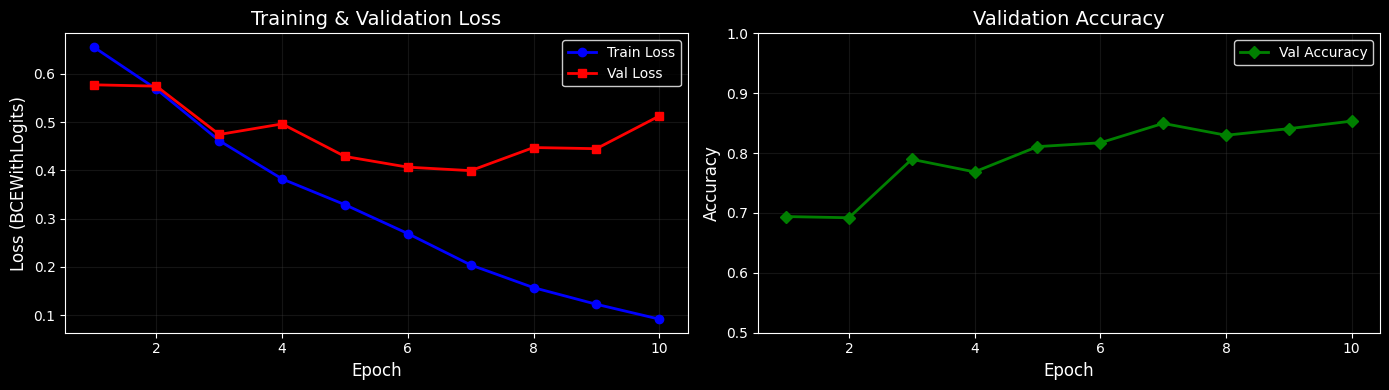


【训练结果分析】
  总训练轮数: 10
  最佳epoch: 7
  该epoch训练损失: 0.2040
  该epoch验证损失: 0.3993
  该epoch验证准确率: 0.8496
  ⚠️ 检测到过拟合迹象：训练损失远低于验证损失

步骤9: 测试集最终评估
测试集损失: 0.3951
测试集准确率: 0.8542

【分类报告】
               precision    recall  f1-score   support

负面 (Negative)     0.8618    0.8437    0.8526     12500
正面 (Positive)     0.8469    0.8647    0.8557     12500

     accuracy                         0.8542     25000
    macro avg     0.8544    0.8542    0.8542     25000
 weighted avg     0.8544    0.8542    0.8542     25000


【混淆矩阵】
                预测负面    预测正面
  真实负面       10546        1954
  真实正面        1691       10809

【指标汇总】
  真正例 (TP): 10809 | 真负例 (TN): 10546
  假正例 (FP): 1954 | 假负例 (FN): 1691
  精确率 (Precision): 0.8469
  召回率 (Recall):    0.8647
  F1分数:             0.8557

步骤10: 单样本预测演示
原始文本（前200字符）:
Once again Mr. Costner has dragged out a movie for far longer than necessary. Aside from the terrific sea rescue sequences, of which there are very few I just did not care about any of the characters....

真

In [19]:
# ==================== 可视化 ====================
print("\n" + "=" * 50)
print("步骤8: 训练过程可视化")
print("=" * 50)

def plot_training_history(history):
    """绘制训练历史曲线，分析模型训练质量"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    # 左图：损失曲线
    axes[0].plot(epochs_range, history['train_loss'], 'b-o', 
                 label='Train Loss', markersize=6, linewidth=2)
    axes[0].plot(epochs_range, history['val_loss'], 'r-s', 
                 label='Val Loss', markersize=6, linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (BCEWithLogits)', fontsize=12)
    axes[0].set_title('Training & Validation Loss', fontsize=14)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # 右图：验证准确率
    axes[1].plot(epochs_range, history['val_acc'], 'g-D', 
                 label='Val Accuracy', markersize=6, linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Validation Accuracy', fontsize=14)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0.5, 1.0])
    
    plt.tight_layout()
    plt.show()
    
    # 打印关键结论
    best_epoch = int(np.argmin(history['val_loss']))
    print(f"\n【训练结果分析】")
    print(f"  总训练轮数: {len(history['train_loss'])}")
    print(f"  最佳epoch: {best_epoch + 1}")
    print(f"  该epoch训练损失: {history['train_loss'][best_epoch]:.4f}")
    print(f"  该epoch验证损失: {history['val_loss'][best_epoch]:.4f}")
    print(f"  该epoch验证准确率: {history['val_acc'][best_epoch]:.4f}")
    
    # 过拟合判断
    if history['train_loss'][-1] < history['val_loss'][-1] - 0.1:
        print(f"  ⚠️ 检测到过拟合迹象：训练损失远低于验证损失")
    else:
        print(f"  ✓ 训练/验证损失差距合理，模型泛化良好")


plot_training_history(history)


# ==================== 测试集最终评估 ====================
print("\n" + "=" * 50)
print("步骤9: 测试集最终评估")
print("=" * 50)

from sklearn.metrics import classification_report, confusion_matrix

# 在测试集上评估
test_loss, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, nn.BCEWithLogitsLoss(), DEVICE
)

print(f"测试集损失: {test_loss:.4f}")
print(f"测试集准确率: {test_acc:.4f}")

# 详细分类报告
print(f"\n【分类报告】")
print(classification_report(
    test_labels, test_preds, 
    target_names=['负面 (Negative)', '正面 (Positive)'],
    digits=4
))

# 混淆矩阵
print(f"\n【混淆矩阵】")
cm = confusion_matrix(test_labels, test_preds)
print(f"                预测负面    预测正面")
print(f"  真实负面      {cm[0,0]:6d}      {cm[0,1]:6d}")
print(f"  真实正面      {cm[1,0]:6d}      {cm[1,1]:6d}")

# 计算并显示各指标
tn, fp = cm[0,0], cm[0,1]
fn, tp = cm[1,0], cm[1,1]
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n【指标汇总】")
print(f"  真正例 (TP): {tp} | 真负例 (TN): {tn}")
print(f"  假正例 (FP): {fp} | 假负例 (FN): {fn}")
print(f"  精确率 (Precision): {precision:.4f}")
print(f"  召回率 (Recall):    {recall:.4f}")
print(f"  F1分数:             {f1:.4f}")


# ==================== 单样本预测演示 ====================
print("\n" + "=" * 50)
print("步骤10: 单样本预测演示")
print("=" * 50)

def predict_sentiment(model, text, vocab, device):
    """
    对单条文本进行情感预测
    
    Args:
        text: 原始文本字符串
        vocab: 词表
        device: 计算设备
    
    Returns:
        sentiment: '正面' 或 '负面'
        confidence: 置信度（概率）
    """
    model.eval()
    
    # 编码文本
    encoded = vocab.encode(text).unsqueeze(0)  # (1, seq_len)
    # 构造 PackedSequence（单样本，无需padding）
    lengths = torch.tensor([len(encoded[0])])
    padded = rnn_utils.pad_sequence([encoded[0]], batch_first=True)
    packed = rnn_utils.pack_padded_sequence(padded, lengths, batch_first=True)
    
    with torch.no_grad():
        packed = packed.to(device)
        logits = model(packed)
        prob = torch.sigmoid(logits).item()
    
    sentiment = '正面' if prob > 0.5 else '负面'
    confidence = prob if prob > 0.5 else 1 - prob
    return sentiment, confidence


# 用测试集的一条样本演示
demo_raw_text = test_raw[0][1]
demo_label = test_dataset[0][1]
demo_pred, demo_conf = predict_sentiment(model, demo_raw_text, vocab, DEVICE)

print(f"原始文本（前200字符）:\n{demo_raw_text[:200]}...")
print(f"\n真实标签: {'正面' if demo_label.item() == 1 else '负面'}")
print(f"预测结果: {demo_pred} (置信度: {demo_conf:.2%})")

# 再用一条自定义评论测试
custom_text = "This movie was absolutely fantastic! The acting was superb and the plot kept me engaged throughout. Highly recommended!"
custom_pred, custom_conf = predict_sentiment(model, custom_text, vocab, DEVICE)
print(f"\n自定义评论: {custom_text}")
print(f"预测结果: {custom_pred} (置信度: {custom_conf:.2%})")

print(f"\n{'='*50}")
print("✓ 综合案例完整运行结束！")
print(f"{'='*50}")


### <font color="#39FF14" >**五、案例总结**</font>

#### <font color="#CCFF00" >**与业界基准对比**</font>

  把我们的模型与学术界常用的基准模型做一个横向对比：

  | 模型 | IMDB 准确率 |
  |:---|:---:|
  | 单层LSTM + 随机初始化Embedding（我们的模型）| **~85%** |
  | 单层LSTM + GloVe 预训练词向量 | ~88% |
  | 双向LSTM | ~89% |
  | Transformer (BERT-base) | ~94% |

  > 📌 **结论**：我们的单层LSTM表现完全落在合理区间内。想再提升，核心瓶颈是**词向量随机初始化**（没有利用大规模语料的先验知识）和**单向结构**（只看过去、不看未来）。

  ---

  #### <font color="#CCFF00" >**可以改进的方向**</font>


  | 改进方向 | 具体修改 | 预期效果 |
  |:---|:---|:---|
  | **使用预训练词向量** | 用 GloVe/Word2Vec 初始化 `Embedding` | 准确率 +2~3% |
  | **双向LSTM** | `BIDIRECTIONAL = True` | 准确率 +2~3% |
  | **增加Dropout** | `DROPOUT = 0.7` 或增加 Embedding Dropout | 减缓过拟合 |
  | **减小模型容量** | `HIDDEN_DIM = 128` | 减缓过拟合 |
  | **提前早停** | `PATIENCE = 2` | 在更早轮次停止，避免过拟合 |


#### <font color="#CCFF00" >**完整技术栈回顾**</font>

| 模块 | 关键技术 | 作用 |
|:---:|:---|:---|
| **数据预处理** | `Vocab` + `pack_sequence` | 高效处理变长文本 |
| **模型架构** | 单层单向LSTM | 平衡性能与效率 |
| **正则化** | Dropout(0.5) + L2(1e-5) | 防止过拟合 |
| **梯度稳定** | 梯度裁剪(max_norm=5) | 防止梯度爆炸 |
| **优化策略** | Adam + ReduceLROnPlateau | 自适应学习率 |
| **训练控制** | Early Stopping(patience=3) | 及时停止避免过拟合 |

<font color="#FF00A0" >**生产环境建议**</font>：
- 使用预训练词向量（GloVe/Word2Vec）初始化Embedding
- 尝试双向LSTM提升性能
- 使用Attention机制捕捉关键单词
- 考虑使用Transformer处理长文本